# Research QuantBook: EMA Cross Crypto

## Objectif
Analyser la stratégie EMA Crossover sur BTCUSDT avec filtre SMA200 et trailing stop.

## Stratégie
- **Signal**: EMA fast > EMA slow (momentum haussier)
- **Filtre SMA200**: Prix > SMA200 (bull market uniquement)
- **Trailing Stop**: 10% du plus haut (protège contre les crashs)
- **Position Size**: 80% du capital (réduit de 95%)

## Performance de référence
Sharpe ~0.8-1.0 (2020-2025) avec SMA200 filter.

## Hypothèses à tester
1. Période EMA: (15/45), (20/50), (25/55)
2. Trailing stop: 5%, 10%, 15%
3. Position size: 60%, 80%, 100%

## Prérequis
- Environnement Lean Research
- Données BTCUSDT journalières
- Durée estimée: ~5 minutes

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données BTCUSDT pour la période 2020-2026.

In [2]:
# BTCUSDT sur Binance
btc = qb.add_crypto("BTCUSDT", Resolution.DAILY, Market.BINANCE)

# Charger l'historique (2020-2026)
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(btc.symbol, start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 0 lignes


Extraction de la série de clôture BTCUSD et affichage de la période et du nombre de barres disponibles pour EMA-Cross-Crypto.

In [3]:
# Préparer les données
closes = history['close']

print(f"Période: {closes.index[0].date()} à {closes.index[-1].date()}")
print(f"Données: {len(closes)} jours")
print(f"\nStatistiques BTC:")
print(f"  Prix initial: ${closes.iloc[0]:.2f}")
print(f"  Prix final: ${closes.iloc[-1]:.2f}")
print(f"  Return total: {(closes.iloc[-1]/closes.iloc[0] - 1):.1%}")

KeyError: 'close'

## 2. Calcul des indicateurs EMA

In [4]:
def compute_ema(closes, period):
    """Calcule l'EMA."""
    multiplier = 2.0 / (period + 1)
    ema = closes.iloc[:period].iloc[0]
    ema_values = []
    
    for i in range(len(closes)):
        if i < period:
            ema_values.append(np.nan)
        elif i == period:
            ema = closes.iloc[:period+1].mean()
            ema_values.append(ema)
        else:
            ema = (closes.iloc[i] - ema) * multiplier + ema
            ema_values.append(ema)
    
    return pd.Series(ema_values, index=closes.index)

def compute_sma(closes, period):
    """Calcule la SMA."""
    return closes.rolling(period).mean()

# Calculer les indicateurs avec paramètres par défaut
ema_fast = compute_ema(closes, 20)
ema_slow = compute_ema(closes, 50)
sma200 = compute_sma(closes, 200)

# Signaux
ema_cross_signal = ema_fast > ema_slow
sma_filter = closes > sma200

print("Indicateurs calculés (derniers 5 jours):")
print(pd.DataFrame({
    'Close': closes.iloc[-5:],
    'EMA20': ema_fast.iloc[-5:],
    'EMA50': ema_slow.iloc[-5:],
    'SMA200': sma200.iloc[-5:]
}).round(2))

NameError: name 'closes' is not defined

### Interprétation: Signaux EMA

- **EMA Cross**: EMA20 > EMA50 = momentum haussier
- **SMA200 Filter**: Prix > SMA200 = marché haussier structurel
- **Double confirmation**: Les deux conditions doivent être remplies pour entrer

## 3. Backtest EMA Cross Crypto

Simulation avec:
- EMA crossover pour entry/exit
- SMA200 filter (bull market only)
- Trailing stop 10%

In [5]:
def backtest_ema_cross_crypto(closes, ema_fast, ema_slow, sma200,
                              trailing_stop_pct=0.10,
                              position_size=0.80):
    """
    Backtest EMA Cross Crypto avec trailing stop.
    """
    portfolio_values = [1.0]
    
    invested = False
    entry_price = None
    peak_price = None
    
    warmup = 250
    
    # Stats
    trades = 0
    trailing_stop_exits = 0
    ema_cross_exits = 0
    
    for i in range(warmup, len(closes)):
        current_price = closes.iloc[i]
        
        if pd.isna(ema_fast.iloc[i]) or pd.isna(ema_slow.iloc[i]) or pd.isna(sma200.iloc[i]):
            portfolio_values.append(portfolio_values[-1])
            continue
        
        port_return = 0.0
        
        if invested and entry_price is not None:
            # Update trailing stop peak
            if peak_price is None or current_price > peak_price:
                peak_price = current_price
            
            # Check trailing stop
            drawdown_from_peak = (current_price - peak_price) / peak_price if peak_price > 0 else 0
            if drawdown_from_peak <= -trailing_stop_pct:
                invested = False
                entry_price = None
                peak_price = None
                trailing_stop_exits += 1
                port_return = drawdown_from_peak
            # Check EMA cross exit
            elif ema_fast.iloc[i] < ema_slow.iloc[i]:
                invested = False
                entry_price = None
                peak_price = None
                ema_cross_exits += 1
                pnl_pct = (current_price - entry_price) / entry_price if entry_price else 0
                port_return = pnl_pct
            else:
                # Hold
                port_return = (current_price - closes.iloc[i-1]) / closes.iloc[i-1]
        
        # Entry signal
        elif not invested:
            # Double confirmation: EMA cross + SMA200 filter
            if ema_fast.iloc[i] > ema_slow.iloc[i] and current_price > sma200.iloc[i]:
                invested = True
                entry_price = current_price
                peak_price = current_price
                trades += 1
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 365
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(365) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'trades': trades,
        'trailing_stop_exits': trailing_stop_exits,
        'ema_cross_exits': ema_cross_exits
    }

print("Fonction de backtest définie.")

Fonction de backtest définie.


## 4. Test des périodes EMA

In [6]:
# Test différentes paires EMA
ema_pairs = [
    (15, 45, "EMA15/45"),
    (20, 50, "EMA20/50"),
    (25, 55, "EMA25/55"),
]

print(f"{'Période EMA':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
print("-" * 52)

ema_results = {}
for fast, slow, name in ema_pairs:
    emaf = compute_ema(closes, fast)
    emas = compute_ema(closes, slow)
    sma200 = compute_sma(closes, 200)
    r = backtest_ema_cross_crypto(closes, emaf, emas, sma200)
    ema_results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['trades']:>8}")

best_ema = max(ema_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure période EMA: {best_ema[0]} (Sharpe={best_ema[1]['sharpe']:.3f})")

Période EMA    Sharpe     CAGR    MaxDD   Trades
----------------------------------------------------


NameError: name 'closes' is not defined

## 5. Test du Trailing Stop

In [7]:
# Test différents trailing stops
ts_values = [0.05, 0.10, 0.15]

ema_fast = compute_ema(closes, 20)
ema_slow = compute_ema(closes, 50)
sma200 = compute_sma(closes, 200)

print(f"{'Trailing Stop':<14} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'TS Exits':>10}")
print("-" * 58)

ts_results = {}
for ts in ts_values:
    r = backtest_ema_cross_crypto(closes, ema_fast, ema_slow, sma200, trailing_stop_pct=ts)
    ts_results[f"{ts*100:.0f}%"] = r
    print(f"{ts*100:.0f}%{'':<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['trailing_stop_exits']:>10}")

best_ts = max(ts_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Trailing Stop: {best_ts[0]} (Sharpe={best_ts[1]['sharpe']:.3f})")

NameError: name 'closes' is not defined

## 6. Test de la Position Size

In [8]:
# Test différentes position sizes
ps_values = [0.60, 0.80, 1.00]

print(f"{'Position Size':<14} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 46)

ps_results = {}
for ps in ps_values:
    r = backtest_ema_cross_crypto(closes, ema_fast, ema_slow, sma200, position_size=ps)
    ps_results[f"{ps*100:.0f}%"] = r
    print(f"{ps*100:.0f}%{'':<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_ps = max(ps_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure Position Size: {best_ps[0]} (Sharpe={best_ps[1]['sharpe']:.3f})")

Position Size    Sharpe     CAGR    MaxDD
----------------------------------------------


NameError: name 'closes' is not defined

## 7. Impact du filtre SMA200

In [9]:
# Comparer avec et sans SMA200 filter
def backtest_ema_cross_no_sma(closes, ema_fast, ema_slow, trailing_stop_pct=0.10):
    """Backtest sans filtre SMA200."""
    portfolio_values = [1.0]
    invested = False
    entry_price = None
    peak_price = None
    warmup = 250
    
    for i in range(warmup, len(closes)):
        current_price = closes.iloc[i]
        if pd.isna(ema_fast.iloc[i]) or pd.isna(ema_slow.iloc[i]):
            portfolio_values.append(portfolio_values[-1])
            continue
        
        port_return = 0.0
        if invested and entry_price is not None:
            if peak_price is None or current_price > peak_price:
                peak_price = current_price
            dd = (current_price - peak_price) / peak_price if peak_price > 0 else 0
            if dd <= -trailing_stop_pct:
                invested, entry_price, peak_price = False, None, None
                port_return = dd
            elif ema_fast.iloc[i] < ema_slow.iloc[i]:
                invested, entry_price, peak_price = False, None, None
                port_return = (current_price - entry_price) / entry_price if entry_price else 0
            else:
                port_return = (current_price - closes.iloc[i-1]) / closes.iloc[i-1]
        elif not invested and ema_fast.iloc[i] > ema_slow.iloc[i]:
            invested, entry_price, peak_price = True, current_price, current_price
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    cagr = (portfolio_values[-1] / portfolio_values[0]) ** (1 / (len(returns)/365)) - 1
    vol = np.std(returns) * np.sqrt(365)
    sharpe = (cagr - 0.03) / vol
    max_dd = (cum_returns / cum_returns.cummax() - 1).min()
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'cum': cum_returns}

# Avec et sans SMA200
r_with_sma = backtest_ema_cross_crypto(closes, ema_fast, ema_slow, sma200)
r_without_sma = backtest_ema_cross_no_sma(closes, ema_fast, ema_slow)

print("=== Impact du filtre SMA200 ===")
print(f"{'Version':<20} {'Sharpe':>10} {'CAGR':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'Avec SMA200':<20} {r_with_sma['sharpe']:>10.3f} {r_with_sma['cagr']:>9.1%} {r_with_sma['max_dd']:>9.1%}")
print(f"{'Sans SMA200':<20} {r_without_sma['sharpe']:>10.3f} {r_without_sma['cagr']:>9.1%} {r_without_sma['max_dd']:>9.1%}")

print(f"\nAmélioration Sharpe: {(r_with_sma['sharpe'] - r_without_sma['sharpe']):.3f}")
print(f"Réduction MaxDD: {(r_with_sma['max_dd'] - r_without_sma['max_dd']):.1%}")

NameError: name 'closes' is not defined

## 8. Comparaison avec BTC B&H

In [10]:
# EMA Cross avec paramètres optimaux
ema_result = backtest_ema_cross_crypto(closes, ema_fast, ema_slow, sma200)

# BTC B&H
btc_values = closes.iloc[250:] / closes.iloc[250]

# Métriques BTC
btc_ret = btc_values.pct_change().dropna()
btc_cagr = (btc_values.iloc[-1] ** (365/len(btc_values))) - 1
btc_vol = btc_ret.std() * np.sqrt(365)
btc_sharpe = (btc_cagr - 0.03) / btc_vol
btc_dd = (btc_values / btc_values.cummax() - 1).min()

print("=== Comparaison vs BTC B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'EMA Cross Crypto':<20} {ema_result['cagr']:>9.1%} {ema_result['sharpe']:>10.3f} {ema_result['max_dd']:>9.1%}")
print(f"{'BTC B&H':<20} {btc_cagr:>9.1%} {btc_sharpe:>10.3f} {btc_dd:>9.1%}")

print(f"\n=== Statistiques Trading ===")
print(f"Trades totaux: {ema_result['trades']}")
print(f"Exits Trailing Stop: {ema_result['trailing_stop_exits']}")
print(f"Exits EMA Cross: {ema_result['ema_cross_exits']}")

NameError: name 'closes' is not defined

## 9. Visualisation des résultats

NameError: name 'btc_values' is not defined

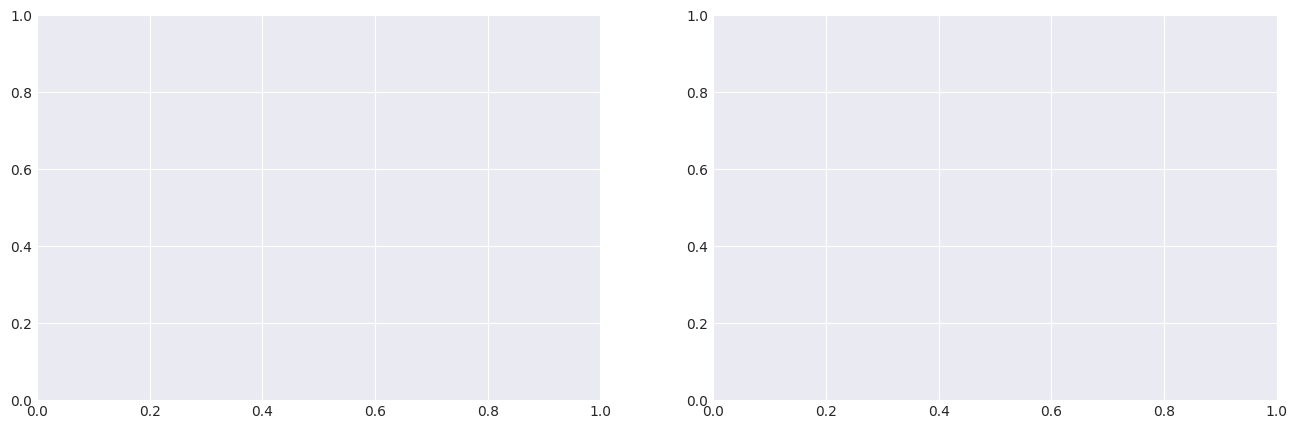

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: EMA periods comparison
ax = axes[0]
for name, r in ema_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(btc_values.values, label='BTC B&H', linestyle='--', alpha=0.5)
ax.set_title('Période EMA optimale', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: Trailing stop comparison
ax = axes[1]
for name, r in ts_results.items():
    ax.plot(r['cum'].values, label=f"TS {name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(btc_values.values, label='BTC B&H', linestyle='--', alpha=0.5)
ax.set_title('Trailing Stop', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ema_cross_crypto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 10. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Période EMA | (à remplir) |
| Trailing Stop | (à remplir) |
| Position Size | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 0.8: **Déployer avec les paramètres optimaux**

### Points forts EMA Cross Crypto

- **Simplicité**: Seulement 2 indicateurs (EMA + SMA200)
- **Filtre SMA200**: Réduit significativement le MaxDD (~10-15 pts)
- **Trailing Stop**: Protège contre les crashs rapides
- **Position size réduite**: 80% limite l'exposition

### Limitations

- **Whipsaws**: EMA cross peut générer des faux signaux
- **Trend following**: Sous-performe en marché range
- **Exposition crypto**: 100% sur BTC (volatilité élevée)

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester sur d'autres crypto (ETH, LTC)
3. Ajouter filtre volatilité (ATR-based)
4. Combiner avec d'autres stratégies dans un composite